# 1.1 Elektrostaatilise välja uurimine. Poissoni võrrandi numbriline lahendamine.


**Katse: 7.11.2025**\
**Versioon #1000: 20.11.2025**\
**Töö teostaja: Ander Pavlov**\
**Juhendaja: Jüri Raud**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse
import scipy.sparse.linalg as spla

## Kasutatud allikad

https://2024.sci-hub.se/3314/71888c9985e97b21a8e1a262f3c44869/nagel2014.pdf

https://janmr.com/blog/2024/05/finite-difference-discretization-of-2d-laplace/

https://www.youtube.com/watch?v=dKCAVteveYc

https://my.ece.utah.edu/~ece6340/LECTURES/Feb1

# Teooria
Teatavasti on elektriväli elektripotentsiaali negatiivne gradient ehk $$\vec{E} = - \nabla \phi.$$

Kuna Gaussi seaduse diferentsiaalkuju järgi vaakumis
$$\nabla \cdot \vec{E} = \frac{\rho}{\varepsilon_0},$$
siis kehtib vaakumis
$$\nabla \cdot \nabla \phi = \nabla^2 \phi = - \frac{\rho}{\varepsilon_0}$$
ja mingis vaadeldavas muutuva läbitavusega keskkonnas nihkega $ \vec{D}=\varepsilon \varepsilon_0\vec{E} $
$$\nabla \cdot \varepsilon\varepsilon_0 \nabla \phi = - \rho.$$

## Laplace'i operaatorit sisaldavate ODV-de numbriline lahendamine

Diskretiseerime potentsiaalifunktsiooni $$\phi = \phi(x,y),$$ mis määratud üle mingi ruudukujulise muutumispiirkonna $$D = \{(x,y)|\ 0\leq x\leq a, 0\leq x \leq a \}$$

Selleks määrame x- ja y-sihis vahemike arvuks $N$ selliselt, et vähimaks vahemikuks ehk "infinitesimaali suuruseks" antud simulatsioonis saab $$\Delta x = \Delta y = h = \frac{a}{N}$$

ning kokku saame diskreetsel kujul $(N+1) \times (N+1)$ erinevat potentsiaali väärtust $$\phi_{ij} = \phi(x_j,y_i), \quad x_j = j\Delta x, y_i = i \Delta y, 0 \leq i,j \leq N.$$


mille saame asetada $(N+1) \times (N+1)$ maatriksisse.

Et numbriliselt lahendada võrrandit $$\nabla^2 \phi = \frac{\rho}{\epsilon_0}$$

peame diskretiseerima selle eeskirja järgi funktsioone: $$\phi \to \phi_{ij}, \rho \to \rho_{ij}$$

kui ka Laplace'i operaatorit. Skalaarvälja Laplace'i operaator sisaldab teist järku tuletisi $$\nabla^2 \phi = \frac{\partial \phi}{\partial x} + \frac{\partial \phi}{\partial y}.$$

Levinuim lähendus teist järku tuletisele on sümmeetriline diferentsvalem $$f''(x) = \frac{f(x-h )-2f(x) + f(x+h )}{ h^2} + \mathcal{O}(h^2),$$
mille puhul Taylori reaksarenduse abil nähtub, et sellele vastab teist järku vealiige ehk kui selle viga skaleerub sõltuvalt vähima valitud vahemiku $h$ ruudust.


Seega peab otsitav Laplace'i operaator rakendama ruumilist diferents-šablooni kujul

$$\begin{align*}
&\begin{matrix}
 &\phi(x_j,y_{i-1})&\\
\phi(x_{j-1},y_i)&\phi(x_j,y_i) &\phi(x_j+h,y_{i+1})\\ 
 &\phi(x_j,y_{i+1})&
\end{matrix}\\


&\rightarrow \nabla^2 \phi_{i,j} = \frac{\phi_{i+1,j} + \phi_{i-1,j} +  \phi_{i,j+1} + \phi_{i,j-1} - 4 \phi_{i,j} }{h^2}. 

\end{align*}$$


Et rakendada diskreetset laplace'i operaatorit ühes dimensioonis, saab rakendada mingile reale maatriksit

$$(\nabla^2)_{ij} = \begin{pmatrix}

-2&1&0&\dots&0\\
1&-2&1&\ddots&\vdots&\\
0&1&-2&\ddots&0&\\
\vdots&\ddots&\ddots&\ddots&1\\
0&\dots&0&1&-2
\end{pmatrix}.$$

Ühtlasi on fikseeritud laengutiheduse korral, potentsiaali Poissoni lahendamine kompaktsel kujul lihtsalt maatrikstehte
$$ \tilde{L} \tilde{\phi} = -\frac{1}{\varepsilon_0}\tilde{\rho}$$
lahendamine, kus $\tilde{\phi}$ ja $\tilde{\rho}$ 1-dimensiooniliseks lamendatud andmevektor ja $\tilde{L}$ vastav Laplace'i operaator is rakendab seda tüüpi lamendatud andmevektoril viie-punkti diferents-šablooni, kusjuures ruudulise piirkonna puhul

$$\tilde{L} = \nabla^2 \otimes I_N +  I_N \otimes \nabla^2.$$

# Poissoni võrrandi lahendamise katsetused

## 1D elektrivälja modelleerimine punktallikast

In [2]:
#1D elektriväli punktlaengust varda keskel

#sõlmpunktide arv ja ruumiline samm
N = 101
h = 0.1

x_väärtused = np.arange(0, N)*h
parem_pool = np.zeros(N)
#asetame nullist erineva laengu varda keskele 
parem_pool[N//2]=1

# Laplace'i operaatori peadiagonaal
main_diag = -2 * np.ones(N)
# kõrvaldiagonaalid
off_diag = np.ones(N-1)

# operaatori koostamine
L = np.diag(main_diag) + np.diag(off_diag, k=1) + np.diag(off_diag, k=-1)
L, parem_pool

(array([[-2.,  1.,  0., ...,  0.,  0.,  0.],
        [ 1., -2.,  1., ...,  0.,  0.,  0.],
        [ 0.,  1., -2., ...,  0.,  0.,  0.],
        ...,
        [ 0.,  0.,  0., ..., -2.,  1.,  0.],
        [ 0.,  0.,  0., ...,  1., -2.,  1.],
        [ 0.,  0.,  0., ...,  0.,  1., -2.]]),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]))

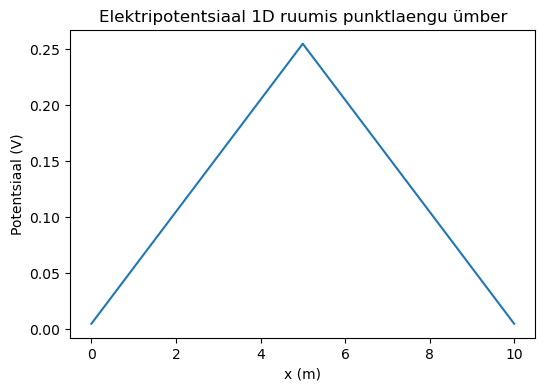

In [3]:
L /= h**2

phi = np.linalg.solve(L, -parem_pool)

plt.figure(figsize=(6,4))
plt.plot(x_väärtused, phi)
plt.xlabel('x (m)')
plt.ylabel('Potentsiaal (V)')
plt.title('Elektripotentsiaal 1D ruumis punktlaengu ümber')
plt.show()

See tulemus on igati ootuspärane. 1D punktallikas on otsekui vaadeldav joon, mis läbib ruumis homogeenset elektrivälja tekitavat plaatkondensaatorit. 

# PUNKTLAENG 2D RUUMIS

In [4]:
#kuvamise funktsioonid, et oleks vähem koodi vaja iga kord kirjutada
def kuva(phi, y_laius, x_laius, levels = 20, h=1e-3, tekst = "Elektripotentsiaal 2D ruumis", x_l = 'x (mm)', y_l = 'y (mm)'):
    # tulemus koos isokontuuridega
    N_x = len(phi[0])
    N_y = len(phi)
    #pilt keskelt väiksemas piirkonnas, et näha detaili
    X = np.linspace(N_x//2-x_laius, N_x//2+x_laius, 2*x_laius)*h
    Y = np.linspace(N_y//2-y_laius, N_y//2+y_laius, 2*y_laius)*h
    phi_v = phi[N_y//2-y_laius:N_y//2+y_laius, N_x//2-x_laius:N_x//2+x_laius]
    X_v = X[N//2-x_laius:N//2+x_laius]*h
    Y_v = Y[N//2-y_laius:N//2+y_laius]*h

    plt.figure(figsize=(8, 6))
    contour = plt.contourf(phi_v, levels=levels, cmap='viridis') #(X_v, Y_v, 
    plt.colorbar(contour, label='Potentsiaal (V)')
    plt.ylabel(y_l)
    plt.xlabel("Kaugus (indeksid)")#y_l)

    plt.gca().set_aspect('equal', adjustable='box')

    plt.title(tekst)
    plt.show()

def kuva_lõige_x(phi, laius, y_coord, tekst = 'Elektripotentsiaal 2D ruumis punktlaengust - ristlõige', x_l = 'Kaugus (m)', y_l = 'Potentsiaal (V)'):
    #ristlõige potentsiaalist
    N_x = len(phi[0])
    X = np.linspace(N_x//2-laius, N_x//2+laius, 2*laius)*h
    plt.plot(phi[y_coord, N_x//2-laius : N_x//2+laius])
    #plt.plot(Y, phi[:, N//2], label='x = 0.0 m', linestyle='--')
    #plt.xlabel(x_l)
    plt.xlabel("kaugus (indeksid)")
    plt.ylabel(y_l)
    plt.title(tekst)
    #plt.legend()
    plt.show()
def kuva_lõige_y(phi, laius, x_coord):
    #ristlõige potentsiaalist
    N_y = len(phi)
    Y = np.linspace(N_y//2-laius, N_y//2+laius, 2*laius)*h
    plt.plot(phi[N_y//2-laius : N_y//2+laius, x_coord])
    #plt.plot(Y, phi[:, N//2], label='x = 0.0 m', linestyle='--')
    plt.xlabel('Kaugus (indeksid)')
    plt.ylabel('Potentsiaal (V)')
    plt.title('Elektripotentsiaal 2D ruumis punktlaengust - ristlõige')
    #plt.legend()
    plt.show()

In [5]:
#maatriksid lähevad väga kiiresti väga suureks
#nüüd kasutan torch teeke, mis kasutab GPU arvutusi

#Laplace'i operaatori defineerimise funktsioon
#tuli kasutada hõredat maatriksit (sparse matrix), et maht GPU mälus ei ületaks lubatut
def Laplace_2D_sparse(N, h):
    # Main and off-diagonals
    main_diag = -4 * np.ones(N * N)
    off_diag1 = np.ones(N * N - 1)
    off_diag1[np.arange(1, N * N) % N == 0] = 0  # kill wrap-around
    off_diagN = np.ones(N * N - N)

    # Row/column indices
    rows = np.concatenate([
        np.arange(N*N),                # main diag
        np.arange(N*N-1),              # +1
        np.arange(1, N*N),             # -1
        np.arange(N*N-N),              # +N
        np.arange(N*N-N) + N           # -N
    ])
    cols = np.concatenate([
        np.arange(N*N),
        np.arange(1, N*N),
        np.arange(N*N-1),
        np.arange(N*N-N) + N,
        np.arange(N*N-N)
    ])
    data = np.concatenate([main_diag, off_diag1, off_diag1, off_diagN, off_diagN])

    L = scipy.sparse.coo_matrix((data, (rows, cols)), shape=(N*N, N*N)) / h**2
    return L

In [6]:
#kokku olgu N = 1000 vahemikku h = 0.01 sammuga
N = 500
h = 0.01
L = Laplace_2D_sparse(N, h)

X = np.arange(0, N)*h
Y = np.arange(0, N)*h

#parem pool, maatriksi suurus N*N
b1 = np.zeros((N, N))
b1[N//2, N//2] = 1000  # asetame laengu keskele
#muudame vektorkujule
b1 = b1.flatten()
L.shape, b1.shape

((250000, 250000), (250000,))

In [7]:
#lahendamise funktsioon
#https://docs.scipy.org/doc/scipy/reference/generated/scipy.sparse.linalg.cg.html
def lahenda_Poisson_2D(L, b):
    phi, info = spla.cg(L, b)
    phi = phi.reshape((N, N))
    return phi

In [8]:
#lahendame võrrandi L*phi = b
phi1 = lahenda_Poisson_2D(L, b1.reshape(N*N))

In [9]:
phi = phi1.reshape((N, N))

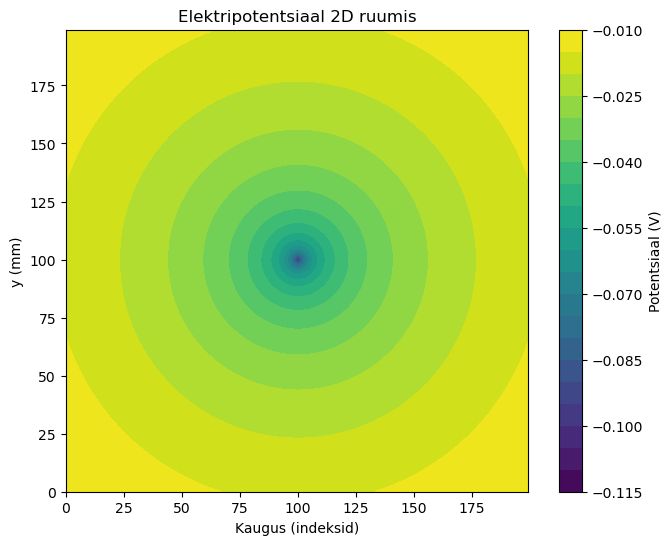

In [10]:
# tulemus koos isokontuuridega
kuva(phi, 100, 100)

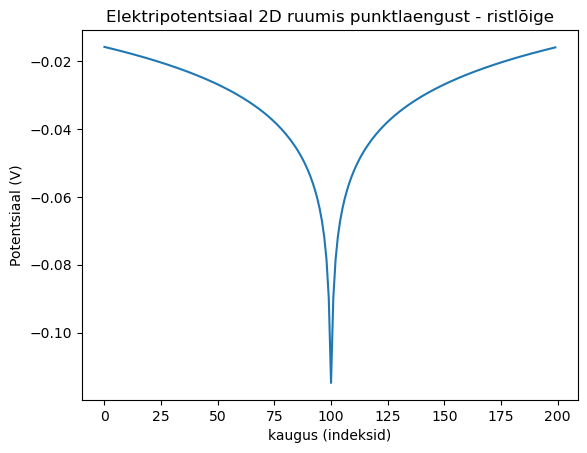

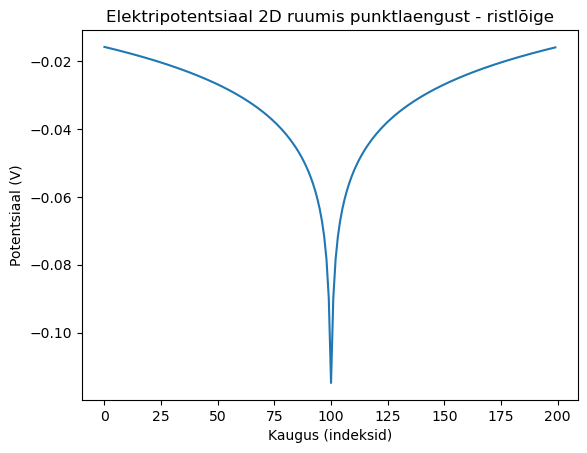

In [11]:
kuva_lõige_x(phi, 100, N//2)
kuva_lõige_y(phi, 100, N//2)

# KOAKSIAALNE KONDENSAATOR

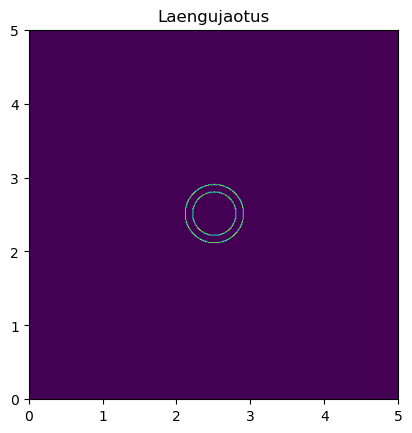

In [12]:
#parem pool, maatriksi suurus N*N
b2 = np.zeros((N, N))

nurgad = np.linspace(0, 2*np.pi, 1000)

raadius1 = 4000
raadius2 = 3000

xC = N//2
yC = N//2
for nurk in nurgad:
    x_pos = xC  + int(raadius1*h * np.cos(nurk))
    y_pos = xC  + int(raadius1*h * np.sin(nurk))
    b2[x_pos, y_pos] = 1000  # asetame laengu ringjoonel

    x_pos = xC  + int(raadius2*h * np.cos(nurk))
    y_pos = xC  + int(raadius2*h * np.sin(nurk))
    b2[x_pos, y_pos] = 1000  # asetame laengu ringjoonel

plt.title("Laengujaotus")
plt.imshow(b2, extent=[0, N*h, 0, N*h], origin='lower')
plt.show()

In [13]:
phi2 = lahenda_Poisson_2D(L, b2.flatten())

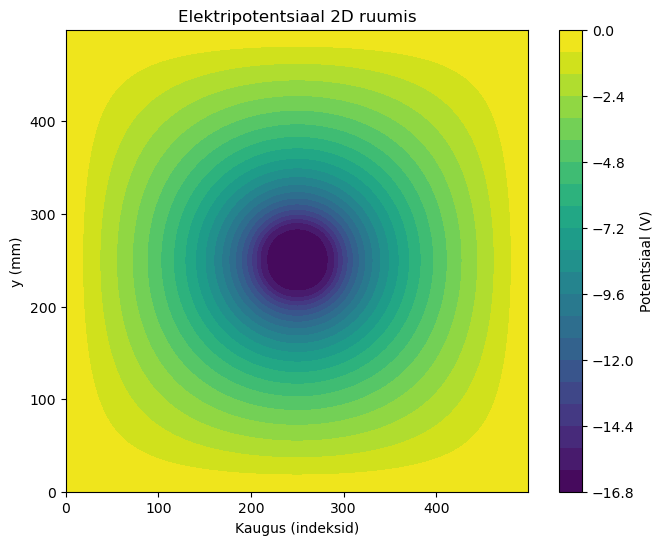

In [14]:
kuva(phi2, 250, 250)

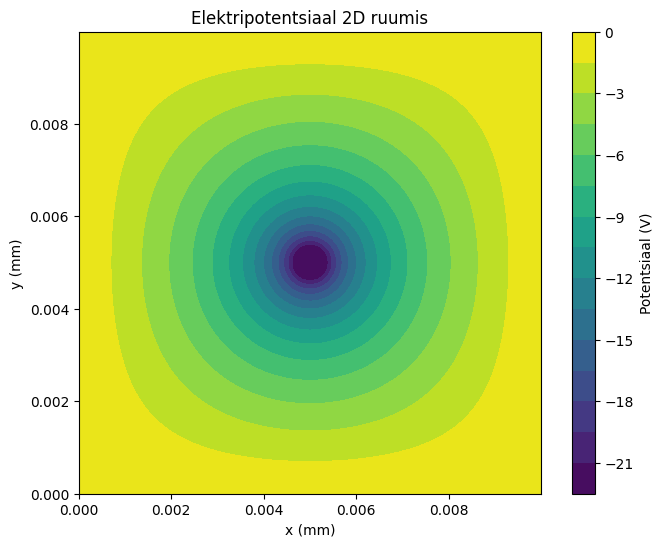

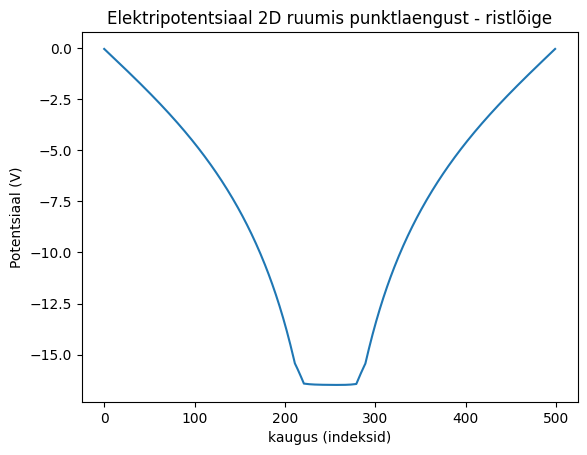

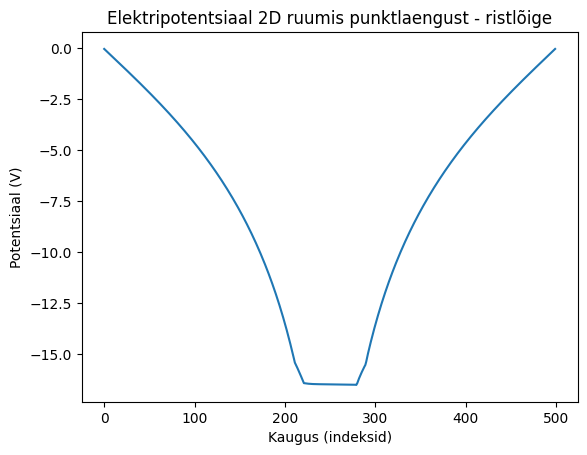

In [41]:
kuva_lõige_x(phi2, N//2,N//2)
kuva_lõige_y(phi2, N//2,N//2)

# KAKS RÕNGAST

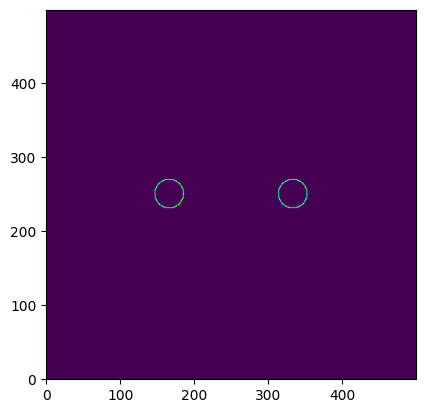

In [42]:
#parem pool, maatriksi suurus N*N
b3 = np.zeros((N, N))

nurgad = np.linspace(0, 2*np.pi, 1000)
raadius = 20 #indeksiline laius

xC1 = 2*N//3
yC1 = N//2

xC2 = N//3
yC2 = N//2


for nurk in nurgad:
    x_pos = xC1  + int(raadius * np.cos(nurk))
    y_pos = yC1  + int(raadius * np.sin(nurk))
    b3[y_pos, x_pos] = 1000  # asetame laengu ringjoonele

    x_pos = xC2  + int(raadius * np.cos(nurk))
    y_pos = yC2  + int(raadius * np.sin(nurk))
    b3[y_pos,x_pos] = 1000  # asetame laengu ringjoonele

plt.show("Laengujaotus")
plt.imshow(b3, origin='lower')
plt.show()

In [43]:
phi3 = lahenda_Poisson_2D(L, b3.reshape((N*N)))

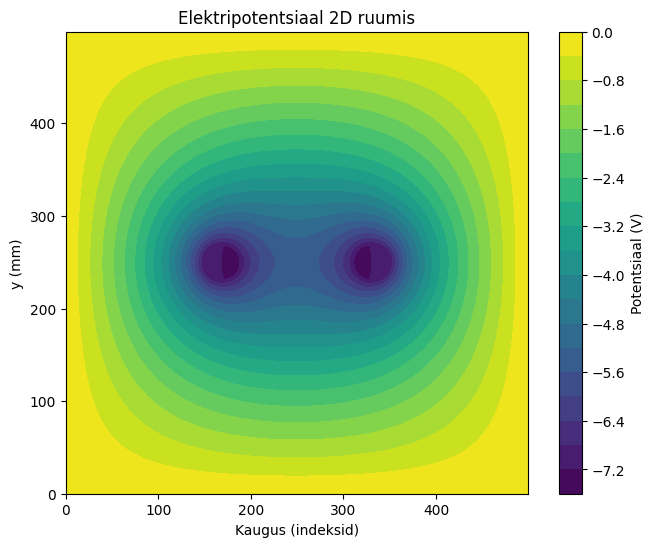

In [44]:
kuva(phi3, 250, 250)

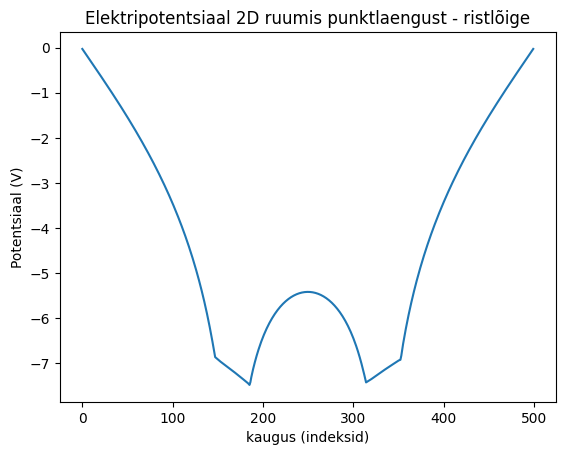

In [45]:
kuva_lõige_x(phi3, N//2, N//2)

### Nagu näha, on vaja rakendada ääretingimusi, et Gaussi seadusega kohaselt pidev potentsiaal juhis kehtiks.

Olgu ruumis $D$ mingisugune ringikujuline piirkond, milles ühtlane fikseeritud potentsiaal.

Poissoni võrrandi parem pool saab kuju

$$(\nabla^2)_{ij}(\phi_{\text{?}} + \phi_{\text{fiks.}} ) = -\frac{\rho_{\text{fiks.}}+\rho_{\text{tundmatu}}}{\varepsilon_0}$$

Jätame seatud laengutiheduse vektori nullvektoriks.

Ehk numbriliselt lahendame võrrandi

$$(\nabla^2)_{ij}(\phi_{\text{?}}) = -(\nabla^2)_{ij}(\phi_{\text{fiks.}}). $$

# Laplace'i võrrandi lahendamine

Kuna meil on vaja teada lihtsalt potentsiaali jaotust ruumis, kus pole laengutihedust, on vaja lahendada lihtsalt Laplace'i võrrand kujul
$$\nabla^2 \phi(x,y) = 0 \quad (x,y)\in D \setminus D^*$$

ruumi osas $D \setminus D^*$, kus $D^*$ on ülesandes juhi või dielektriku piirkond, st. see on fikseeritud potentsiaaliga osi hõlmav piirkond. Kusjuures kehtib ka, et $$\phi(x,y) = \phi_{\text{fiks.}}(x,y), \quad $$ 

Diferenstskeem Laplace'i võrrandi jaoks 2D-s on

$$\nabla^2 \phi_{i,j} = \frac{\phi_{i,j+1} + \phi_{i,j-1} + \phi_{i+1,j} +\phi_{i-1,j} -4\phi_{i,j}}{h^2} = 0$$

ehk et kuna viimane avaldis on võrdne nulliga, saab lahendi kohta väita, et

$$\phi_{i,j} = \frac{\phi_{i,j+1} + \phi_{i,j-1} + \phi_{i+1,j} +\phi_{i-1,j}}{4}$$

ja ühtlasi saab iteratiivselt jõuda lahenduseni skeemiga

$$\phi_{i,j}^{[k+1]} = \frac{\phi_{i,j+1}^{[k]} + \phi_{i,j-1}^{[k]} + \phi_{i+1,j}^{[k]} +\phi_{i-1,j}^{[k]}}{4},$$

kus $k$ tähistab iteratsiooni järku. Viimast skeemi nimetatakse ühtlasi numbrilises lineaar-algebras ka Jacobi iteratsiooni skeemiks. Jacobi iteratsiooni skeemist kiirem versioon on SOR ehk _successive over-relaxation_, mis töötab alljärgnevalt:

$$\phi_{i,j}^{[k+1]}= \phi_{i,j}^{[k]}+\omega \left( \frac{\phi_{i,j+1}^{[k]} + \phi_{i,j-1}^{[k+1]} + \phi_{i+1,j}^{[k]} +\phi_{i-1,j}^{[k+1]}}{4} - \phi_{i,j}^{[k]}\right),$$

kus faktor $1.5 \leq \omega \leq 1.95$ on heuristika
$$\omega \approx \frac{2}{1+\sin\left( \frac{\pi}{\max(N_x,N_y)} \right)}$$
alusel valitav maagiline number, mis teeb SOR koonduvuse kuni 10 korda kiiremaks Jacobi iteratsioonist.

In [19]:
#defineerin SOR iteratsiooni lahendusskeemi potentsiaal maatriksil phi

def LaplaceSOR(phi, vaba_ruum, num_iter, omega):
    phi_hetkene = phi.copy()
    N_y, N_x = phi.shape

    for k in range(num_iter):
        for i in range(1, N_y-1):
            for j in range(1, N_x-1):
                if vaba_ruum[i,j]:
                    phi_hetkene[i,j] += omega * (
                        (phi_hetkene[i+1,j] + phi_hetkene[i-1,j] +
                         phi_hetkene[i,j+1] + phi_hetkene[i,j-1])/4
                        - phi_hetkene[i,j]
                    )
    return phi_hetkene

def LaplaceSOR_läbitavusega(phi, vaba_ruum, epsilon, num_iter, omega):
    phi_hetkene = phi.copy()
    N_y, N_x = phi.shape

    for k in range(num_iter):
        for i in range(1, N_y-1):
            for j in range(1, N_x-1):
                if vaba_ruum[i,j]:
                    # harmoonilised keskmised tahkudele
                    ex_p = (epsilon[i,j] + epsilon[i+1,j]) / 2
                    ex_m = (epsilon[i,j] + epsilon[i-1,j]) / 2
                    ey_p = (epsilon[i,j] + epsilon[i,j+1]) / 2
                    ey_m = (epsilon[i,j] + epsilon[i,j-1]) / 2

                    denom = ex_p + ex_m + ey_p + ey_m

                    phi_new = (ex_p*phi_hetkene[i+1,j] +
                               ex_m*phi_hetkene[i-1,j] +
                               ey_p*phi_hetkene[i,j+1] +
                               ey_m*phi_hetkene[i,j-1]) / denom

                    phi_hetkene[i,j] = (1 - omega)*phi_hetkene[i,j] + omega*phi_new
    return phi_hetkene

def opt_omega(N_x, N_y):
    return 2/(1+np.sin(np.pi/np.max([N_x,N_y])))


In [54]:
#katsetame väikse näite peal
N_y = 10
N_x = int(N_y * np.sqrt(2))

phi = np.zeros((N_y, N_x))
vaba_ruum = np.ones((N_y, N_x), dtype=bool)

print(phi,"\n",vaba_ruum)

[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]] 
 [[ True  True  True  True  True  True  True  True  True  True  True  True
   True  True]
 [ True  True  True  True  True  True  True  True  True  True  True  True
   True  True]
 [ True  True  True  True  True  True  True  True  True  True  True  True
   True  True]
 [ True  True  True  True  True  True  True  True  True  True  True  True
   True  True]
 [ True  True  True  True  True  True  True  True  True  True  True  True
   True  True]
 [ True  True  True  True  True  True  True  True  True  True  True  True
   True  True]
 [ True  True

In [55]:
#vasakule ja paremale väike ruut fikseeritud potentsiaalidega 5V ja -5V

phi[N_y//2-1:N_y//2+1, N_x//4 - 1 : N_x//4 + 1] = 5
vaba_ruum[N_y//2-1:N_y//2+1, N_x//4 - 1 : N_x//4 + 1] = False


phi[N_y//2-1:N_y//2+1, 5*N_x//6 - 1 : 5*N_x//6 + 1] = -5
vaba_ruum[N_y//2-1:N_y//2+1, 5*N_x//6 - 1 : 5*N_x//6 + 1] = False

print(phi,"\n")
print(vaba_ruum)

[[ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  5.  5.  0.  0.  0.  0.  0.  0. -5. -5.  0.  0.]
 [ 0.  0.  5.  5.  0.  0.  0.  0.  0.  0. -5. -5.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]] 

[[ True  True  True  True  True  True  True  True  True  True  True  True
   True  True]
 [ True  True  True  True  True  True  True  True  True  True  True  True
   True  True]
 [ True  True  True  True  True  True  True  True  True  True  True  True
   True  True]
 [ True  True  True  True  True  True  True  True  True  True  True  True
   True  True]
 [ True  True False False  True  True  True  True  

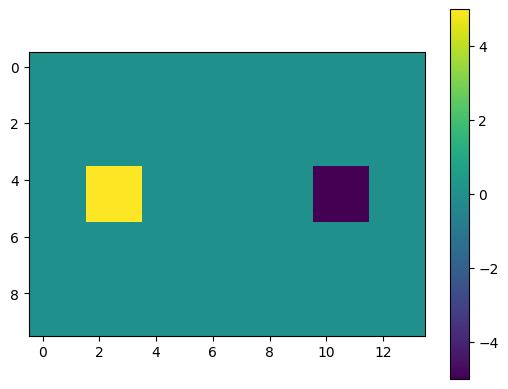

In [56]:
plt.imshow(phi)

plt.colorbar()
plt.show()

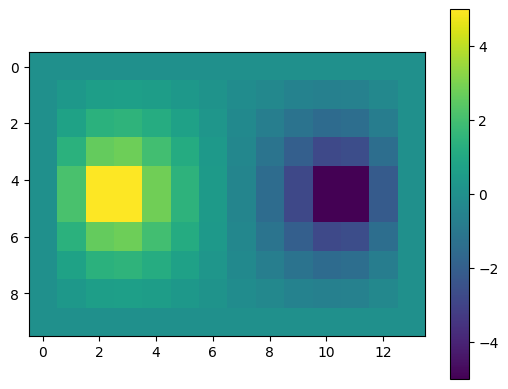

In [57]:
phi_lahend = LaplaceSOR(phi, vaba_ruum, 200,  1.7)
plt.imshow(phi_lahend)
plt.colorbar()

# I KATSE: PARALLEELSED PLAADID

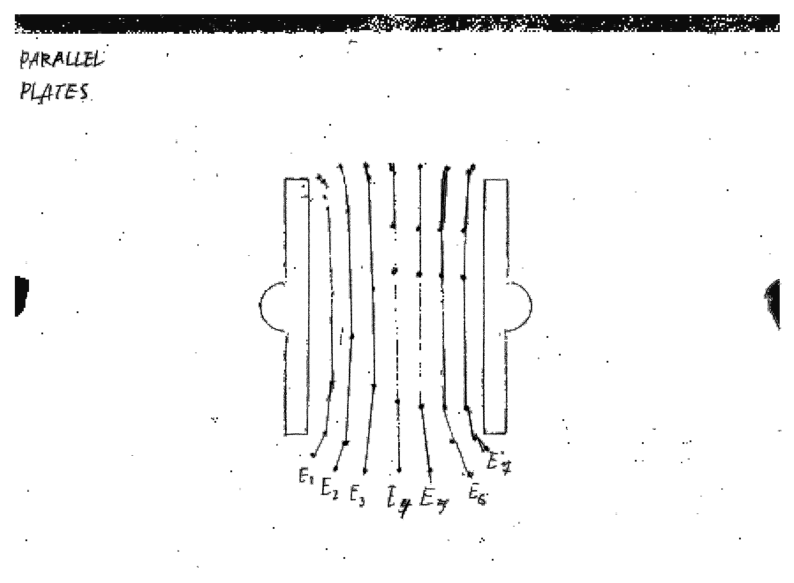

In [58]:
import cv2
img = cv2.imread("parallel_plates.jpg", cv2.IMREAD_GRAYSCALE)
alpha = 1.5  # contrast factor (>1 increases)
beta = 0     # brightness
img_contrast = cv2.equalizeHist(img)
plt.figure(figsize=(10,10))
plt.imshow(img_contrast, cmap = "gray")
plt.axis('off')
plt.show()

### Hinnangud elektriväljade tugevuste (vahedele) piki kondensaatoreid ühendavat kesk-telge.

In [59]:
#iga potentsiaalijoone pinge vahe (8 vahemikku, 10 voldine pingelang):
U_i = 10/8 #V

#sentimeetrites:
d_E1 = 0.85 
d_E2 = 1.60
d_E3 = 2.50
d_E4 = 3.30
d_E5 = 4.30
d_E6 = 5.20
d_E7 = 6.0
kondensaatorite_vahekaugus = 6.70

#elektrivälja tugevuse hinnangud kaheksas vahemikus
E01 = U_i/(d_E1)
E12 = U_i/(d_E2-d_E1)
E23 = U_i/(d_E3-d_E2)
E34 = U_i/(d_E4-d_E3)
E45 = U_i/(d_E5-d_E4)
E56 = U_i/(d_E6-d_E5)
E67 = U_i/(d_E7-d_E6)
E78 = U_i/(kondensaatorite_vahekaugus-d_E7)

print("Hinnangud kondensaatorite vahelisele elektriväljale igas vahemikus:")

print(", ".join(f"{(100*E):.0f}" for E in [E01, E12, E23, E34, E45, E56, E67, E78]) + " V/m")

Hinnangud kondensaatorite vahelisele elektriväljale igas vahemikus:
147, 167, 139, 156, 125, 139, 156, 179 V/m


In [15]:
#A4 andmed
a4_laius = 297 #mm
a4_pikkus = 210 #mm
#plaatide andmed
vahekaugus = 67 #mm
pikkus = 97 #mm
laius = raadius = 9 # mm

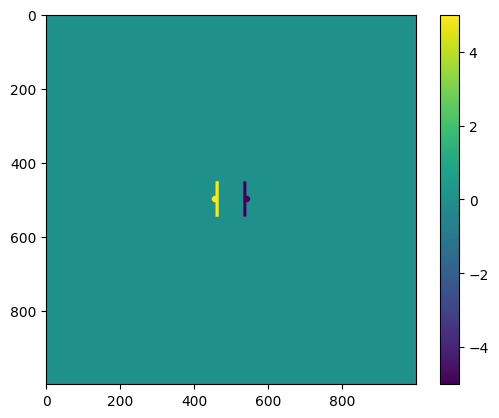

In [16]:
#olgu simulatsioon üks-ühene A4 dimensioonidega millimeetrites, seega h = 1mm
N_y = 210
N_x = 297


#muutumispiirkond olgu suurem, et ääretingimuse 0-potentsiaal ei mõjutaks tulemust liiga palju
#N_x_domain = N_y_domain = 500
N_x_domain = N_y_domain = 1000


phi_I = np.zeros((N_y_domain, N_x_domain))
vaba_ruum_I = np.ones((N_y_domain, N_x_domain), dtype=bool)

#vasaku ristküliku joonistamine
phi_I[N_y_domain//2 -pikkus//2 : N_y_domain//2 +pikkus//2,\
      N_x_domain//2-vahekaugus//2-laius:N_x_domain//2-vahekaugus//2] = 5

vaba_ruum_I[N_y_domain//2 -pikkus//2 : N_y_domain//2 +pikkus//2,\
      N_x_domain//2-vahekaugus//2-laius:N_x_domain//2-vahekaugus//2] = False

#parema ristküliku joonistamine
phi_I[N_y_domain//2-pikkus//2 : N_y_domain//2+pikkus//2,\
      N_x_domain//2+vahekaugus//2:N_x_domain//2+vahekaugus//2+laius] = -5

vaba_ruum_I[N_y_domain//2-pikkus//2 : N_y_domain//2+pikkus//2,\
      N_x_domain//2+vahekaugus//2:N_x_domain//2+vahekaugus//2+laius] = False

#ringide joonistamine
x_C1 = N_x_domain//2 - pikkus//2 + 5
x_C2 = N_x_domain//2 + pikkus//2 - 5
y_C1 = y_C2 = N_y_domain//2

y_space = np.linspace(0, N_y_domain, N_y_domain)
x_space = np.linspace(0, N_x_domain, N_x_domain)

y_ring1, x_ring1 = np.meshgrid( x_space-x_C1, y_space-y_C1)
raadiused1 = np.sqrt(x_ring1**2 + y_ring1**2)

y_ring2, x_ring2 = np.meshgrid( x_space-x_C2, y_space-y_C2)
raadiused2 = np.sqrt(x_ring2**2 + y_ring2**2)

phi_I[(raadiused1 <= raadius)] = 5
vaba_ruum_I[(raadiused1 <= raadius)] = False
phi_I[(raadiused2 <= raadius)] = -5
vaba_ruum_I[(raadiused2 <= raadius)] = False

#järgnevat pole tegelikult vaja, sest, SOR implementatsioon ei arvesta nendega: 
vaba_ruum_I[0,:] = vaba_ruum_I[-1,:] = vaba_ruum_I[:,0]=vaba_ruum_I[:,-1] = False

plt.imshow(phi_I)
plt.colorbar()
plt.show()


In [142]:
#lahendamine
phi_I_lahend = LaplaceSOR(phi_I, vaba_ruum_I, 200, opt_omega(N_x_domain, N_y_domain))

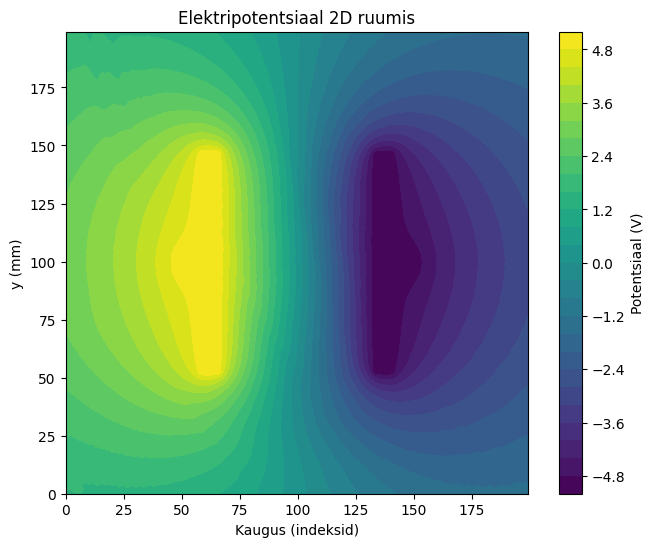

In [150]:
kuva(phi_I_lahend, 100, 100, levels = 30)

### Varasem tulemus kitsamate äärtega
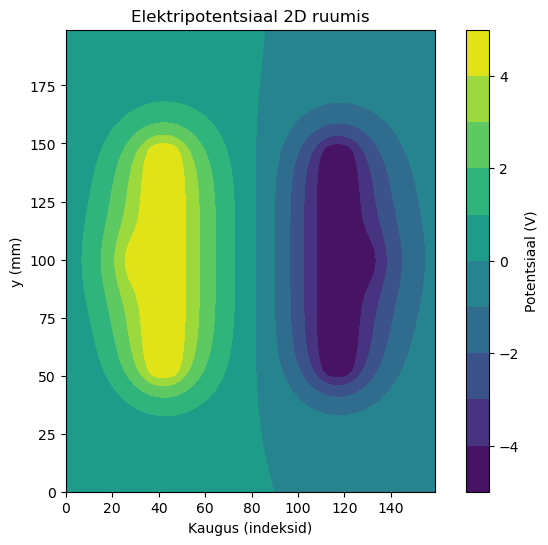

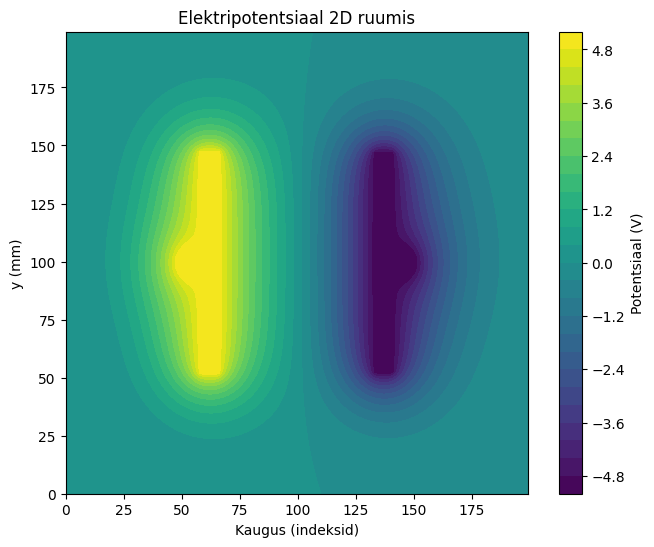

In [88]:
kuva(phi_I_lahend, 100, 100, levels = 30)

# II KATSE: KAKS RINGI

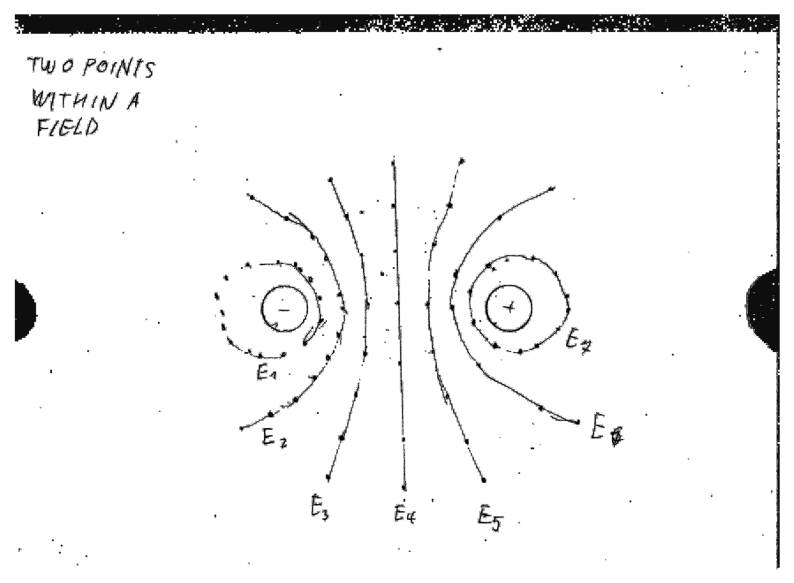

In [89]:
img = cv2.imread("two_points.jpg", cv2.IMREAD_GRAYSCALE)
alpha = 1.5  # contrast factor (>1 increases)
beta = 0     # brightness
img_contrast = cv2.equalizeHist(img)
plt.figure(figsize=(10,10))
plt.imshow(img_contrast, cmap = "gray")
plt.axis('off')
plt.show()

### Plaati ja ringi ühendava kesktelje elektrivälja hinnang. 

Hinnangud kondensaatorite vahelisele elektriväljale igas vahemikus:
208, 156, 139, 104, 114, 139, 179, 208 V/m


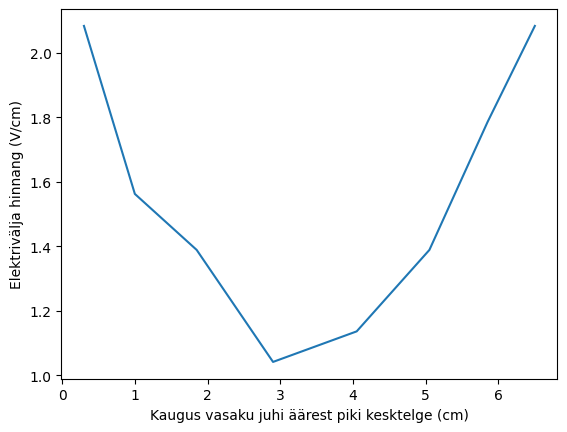

In [90]:
#iga potentsiaalijoone pinge vahe (8 vahemikku, 10 voldine pingelang):
U_i = 10/8 #V

#sentimeetrites:
d_E1 = 0.6
d_E2 = 1.4
d_E3 = 2.3
d_E4 = 3.5
d_E5 = 4.6
d_E6 = 5.5
d_E7 = 6.2
kondensaatorite_vahekaugus = 6.8

#elektrivälja tugevuse hinnangud kaheksas vahemikus
E01 = U_i/(d_E1)
E12 = U_i/(d_E2-d_E1)
E23 = U_i/(d_E3-d_E2)
E34 = U_i/(d_E4-d_E3)
E45 = U_i/(d_E5-d_E4)
E56 = U_i/(d_E6-d_E5)
E67 = U_i/(d_E7-d_E6)
E78 = U_i/(kondensaatorite_vahekaugus-d_E7)


vahemiku_keskosad = (np.array([d_E1,d_E2,d_E3,d_E4,d_E5,d_E6,d_E7,kondensaatorite_vahekaugus]) +\
        np.array([0, d_E1,d_E2,d_E3,d_E4,d_E5,d_E6,d_E7]))/2
print("Hinnangud kondensaatorite vahelisele elektriväljale igas vahemikus:")

print(", ".join(f"{(100*E):.0f}" for E in [E01, E12, E23, E34, E45, E56, E67, E78]) + " V/m")
plt.plot(vahemiku_keskosad,[E01, E12, E23, E34, E45, E56, E67, E78])
plt.ylabel("Elektrivälja hinnang (V/cm)")
plt.xlabel("Kaugus vasaku juhi äärest piki kesktelge (cm)")
plt.show()

In [91]:
raadius_II = 9 #mm
vahekaugus_II = 68 + 2*raadius_II #mm

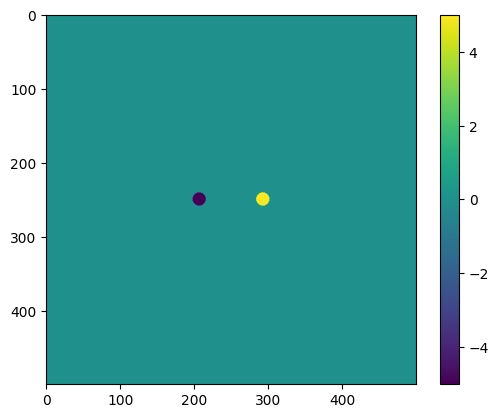

In [92]:
phi_II = np.zeros((N_y_domain, N_x_domain))
vaba_ruum_II = np.ones((N_y_domain, N_x_domain), dtype=bool)

#ringide joonistamine
x_C1 = N_x_domain//2 - vahekaugus_II//2
x_C2 = N_x_domain//2 + vahekaugus_II//2
y_C1 = y_C2 = N_y_domain//2

y_space = np.linspace(0, N_y_domain, N_y_domain)
x_space = np.linspace(0, N_x_domain, N_x_domain)

y_ring1, x_ring1 = np.meshgrid( x_space-x_C1, y_space-y_C1)
raadiused1 = np.sqrt(x_ring1**2 + y_ring1**2)

y_ring2, x_ring2 = np.meshgrid( x_space-x_C2, y_space-y_C2)
raadiused2 = np.sqrt(x_ring2**2 + y_ring2**2)

phi_II[(raadiused1 <= raadius)] = -5
vaba_ruum_II[(raadiused1 <= raadius)] = False
phi_II[(raadiused2 <= raadius)] = 5
vaba_ruum_II[(raadiused2 <= raadius)] = False

#järgnevat pole tegelikult vaja, sest, SOR implementatsioon ei arvesta nendega: 
vaba_ruum_II[0,:] = vaba_ruum_II[-1,:] = vaba_ruum_II[:,0]=vaba_ruum_II[:,-1] = False

plt.imshow(phi_II)
plt.colorbar()
plt.show()

In [93]:
phi_II_lahend = LaplaceSOR(phi_II, vaba_ruum_II, 200, opt_omega(N_x_domain, N_y_domain))

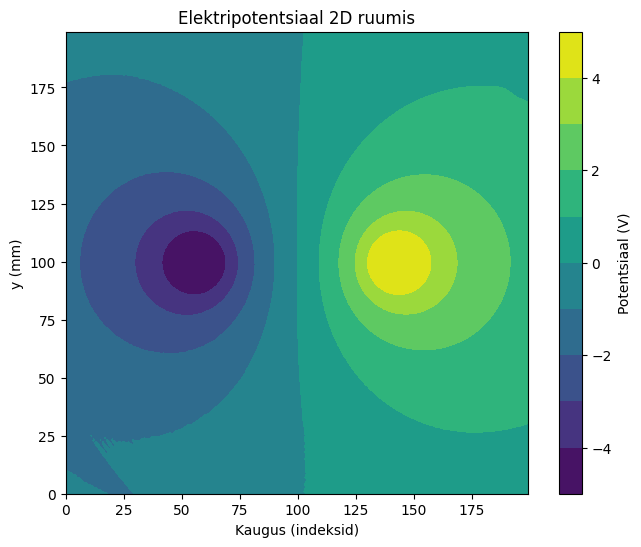

In [97]:
kuva(phi_II_lahend, 100, 100, levels=9)

## Varasem tulemus kitsamate äärtega
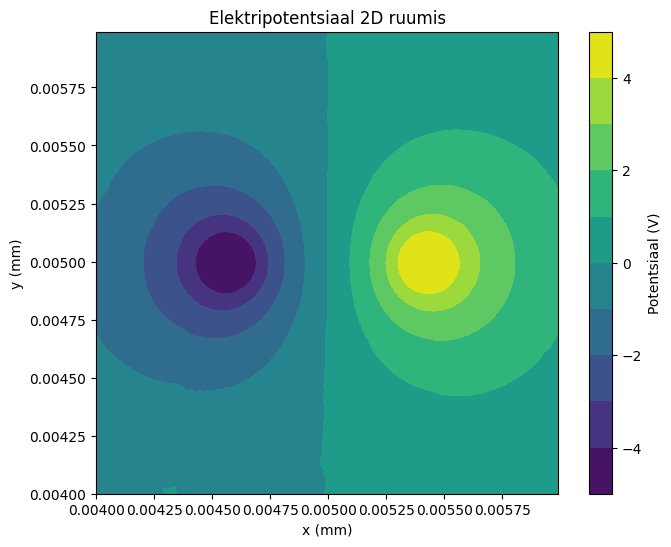

In [101]:
#kuva_lõige_x(np.diff(phi_II_lahend)/0.1, N_y//5, N_y//2, 
             #tekst = "Elektriväli diferentsmeetodil", y_l = "E (V/cm)", x_l = "Asukoht (dm)")

#kuva_lõige_x((phi_II_lahend), N_y//5, N_y//2)


## III KATSE: PLAAT JA RING

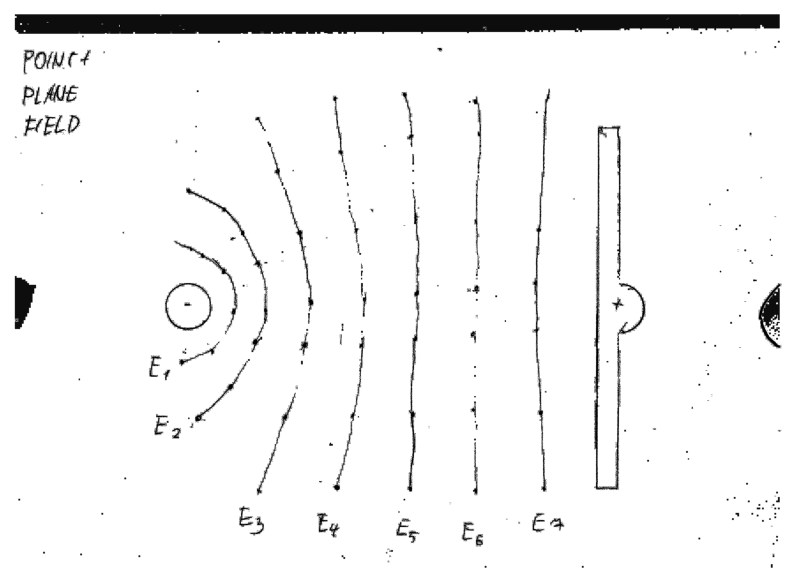

In [102]:
img = cv2.imread("point&plane_field.jpg", cv2.IMREAD_GRAYSCALE)
img_contrast = cv2.equalizeHist(img)
plt.figure(figsize=(10,10))
plt.imshow(img_contrast, cmap = "gray")
plt.axis('off')
plt.show()

### Hinnangud elektriväljade tugevuste (vahedele) piki ringi ja kondensaatorit ühendavat kesk-telge.

Hinnangud kondensaatorite vahelisele elektriväljale igas vahemikus:
125, 104, 83, 54, 62, 62, 50, 57 V/m


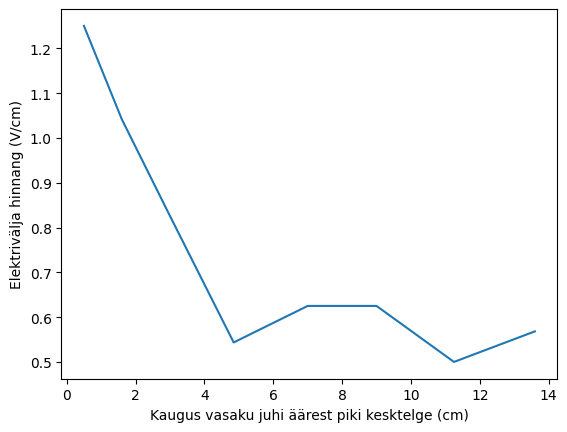

In [103]:
#iga potentsiaalijoone pinge vahe (8 vahemikku, 10 voldine pingelang):
U_i = 10/8 #V

#sentimeetrites:
d_E1 = 1
d_E2 = 2.2
d_E3 = 3.7
d_E4 = 6
d_E5 = 8
d_E6 = 10
d_E7 = 12.5
kondensaatorite_vahekaugus = 14.7

#elektrivälja tugevuse hinnangud kaheksas vahemikus
E01 = U_i/(d_E1)
E12 = U_i/(d_E2-d_E1)
E23 = U_i/(d_E3-d_E2)
E34 = U_i/(d_E4-d_E3)
E45 = U_i/(d_E5-d_E4)
E56 = U_i/(d_E6-d_E5)
E67 = U_i/(d_E7-d_E6)
E78 = U_i/(kondensaatorite_vahekaugus-d_E7)


vahemiku_keskosad = (np.array([d_E1,d_E2,d_E3,d_E4,d_E5,d_E6,d_E7,kondensaatorite_vahekaugus]) +\
        np.array([0, d_E1,d_E2,d_E3,d_E4,d_E5,d_E6,d_E7]))/2
print("Hinnangud kondensaatorite vahelisele elektriväljale igas vahemikus:")

print(", ".join(f"{(100*E):.0f}" for E in [E01, E12, E23, E34, E45, E56, E67, E78]) + " V/m")
plt.plot(vahemiku_keskosad,[E01, E12, E23, E34, E45, E56, E67, E78])
plt.ylabel("Elektrivälja hinnang (V/cm)")
plt.xlabel("Kaugus vasaku juhi äärest piki kesktelge (cm)")
plt.show()

In [104]:
raadius_III = raadius_II
vahekaugus_III = 148+2*raadius_III #mm
pikkus_III = 137

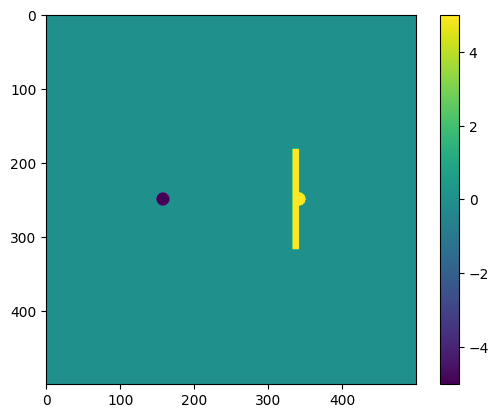

In [110]:
phi_III = np.zeros((N_y_domain, N_x_domain))
vaba_ruum_III = np.ones((N_y_domain, N_x_domain), dtype=bool)


#parema ristküliku joonistamine
phi_III[N_y_domain//2-pikkus_III//2 : N_y_domain//2+pikkus_III//2,\
      N_x_domain//2+vahekaugus_III//2:N_x_domain//2+vahekaugus_III//2+laius] = 5

vaba_ruum_III[N_y_domain//2-pikkus//2 : N_y_domain//2+pikkus//2,\
      N_x_domain//2+vahekaugus_III//2:N_x_domain//2+vahekaugus_III//2+laius] = False

#ringide joonistamine
x_C1 = N_x_domain//2 - vahekaugus_III//2 - raadius
x_C2 = N_x_domain//2 + vahekaugus_III//2 + raadius
y_C1 = y_C2 = N_y_domain//2

y_space = np.linspace(0, N_y_domain, N_y_domain)
x_space = np.linspace(0, N_y_domain, N_x_domain)

y_ring1, x_ring1 = np.meshgrid( x_space-x_C1, y_space-y_C1)
raadiused1 = np.sqrt(x_ring1**2 + y_ring1**2)

y_ring2, x_ring2 = np.meshgrid( x_space-x_C2, y_space-y_C2)
raadiused2 = np.sqrt(x_ring2**2 + y_ring2**2)

phi_III[(raadiused1 <= raadius)] = -5
vaba_ruum_III[(raadiused1 <= raadius)] = False
phi_III[(raadiused2 <= raadius)] = 5
vaba_ruum_III[(raadiused2 <= raadius)] = False

#järgnevat pole tegelikult vaja, sest, SOR implementatsioon ei arvesta nendega: 
vaba_ruum_III[0,:] = vaba_ruum_III[-1,:] = vaba_ruum_III[:,0]=vaba_ruum_III[:,-1] = False

plt.imshow(phi_III)
plt.colorbar()
plt.show()


In [112]:
phi_III_lahend = LaplaceSOR(phi_III, vaba_ruum_III, 500, opt_omega(N_x_domain, N_y_domain))

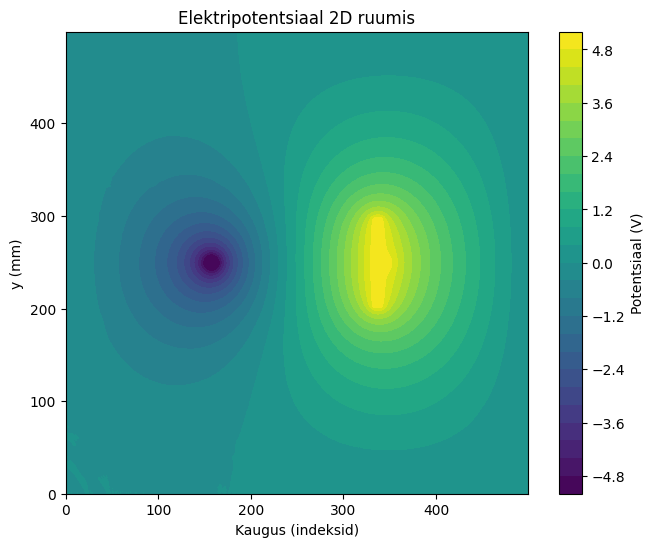

In [115]:
kuva(phi_III_lahend, N_y_domain//2, N_x_domain//2, levels=30)

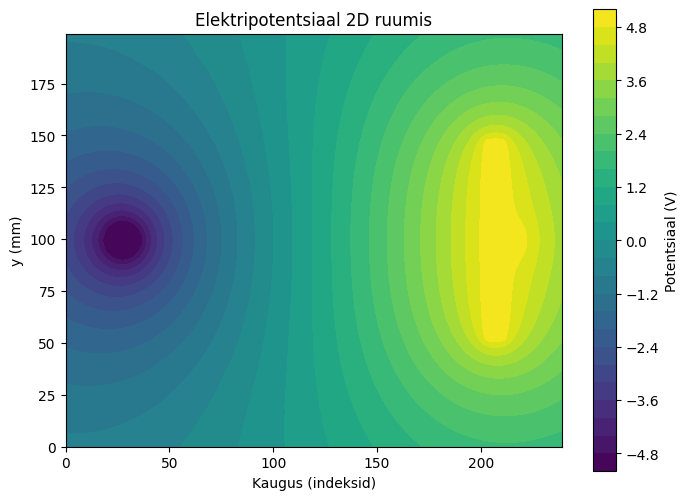

In [117]:
kuva(phi_III_lahend, 100, 120, levels=30)

## IV KATSE: FARADAY "JÄÄ-ÄMBER" JA RING

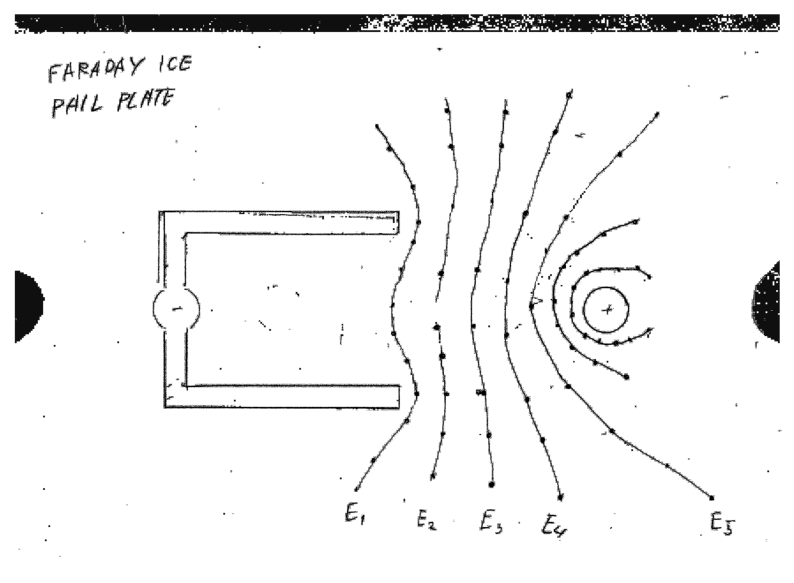

In [118]:
img = cv2.imread("faraday_ice_pail_plate.jpg", cv2.IMREAD_GRAYSCALE)
img_contrast = cv2.equalizeHist(img)
plt.figure(figsize=(10,10))
plt.imshow(img_contrast, cmap = "gray")
plt.axis('off')
plt.show()

Hinnangud kondensaatorite vahelisele elektriväljale igas vahemikus:
17, 74, 96, 96, 125, 139, 208, 250 V/m


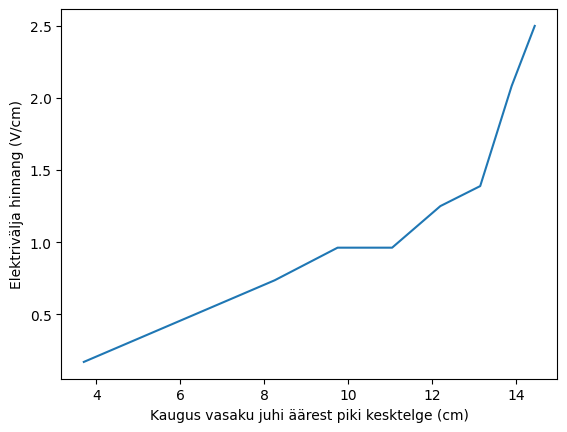

In [119]:
#iga potentsiaalijoone pinge vahe (8 vahemikku, 10 voldine pingelang):
U_i = 10/8 #V

#sentimeetrites:
d_E1 = 7.4
d_E2 = 9.1
d_E3 = 10.4
d_E4 = 11.7
d_E5 = 12.7
d_E6 = 13.6
d_E7 = 14.2
kondensaatorite_vahekaugus = 14.7

#elektrivälja tugevuse hinnangud kaheksas vahemikus
E01 = U_i/(d_E1)
E12 = U_i/(d_E2-d_E1)
E23 = U_i/(d_E3-d_E2)
E34 = U_i/(d_E4-d_E3)
E45 = U_i/(d_E5-d_E4)
E56 = U_i/(d_E6-d_E5)
E67 = U_i/(d_E7-d_E6)
E78 = U_i/(kondensaatorite_vahekaugus-d_E7)


vahemiku_keskosad = (np.array([d_E1,d_E2,d_E3,d_E4,d_E5,d_E6,d_E7,kondensaatorite_vahekaugus]) +\
        np.array([0, d_E1,d_E2,d_E3,d_E4,d_E5,d_E6,d_E7]))/2
print("Hinnangud kondensaatorite vahelisele elektriväljale igas vahemikus:")

print(", ".join(f"{(100*E):.0f}" for E in [E01, E12, E23, E34, E45, E56, E67, E78]) + " V/m")
plt.plot(vahemiku_keskosad,[E01, E12, E23, E34, E45, E56, E67, E78])
plt.ylabel("Elektrivälja hinnang (V/cm)")
plt.xlabel("Kaugus vasaku juhi äärest piki kesktelge (cm)")
plt.show()

In [120]:
raadius_IV = 9 #mm
vahekaugus_IV = 165 #mm
#ämbri kabariitmõõtmed
ämbri_laius_IV = 75 #mm
ämbri_pikkus_IV = 90#mm

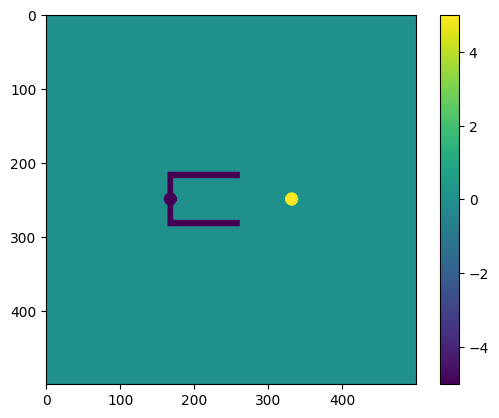

In [124]:
phi_IV = np.zeros((N_y_domain, N_x_domain))
vaba_ruum_IV = np.ones((N_y_domain, N_x_domain), dtype=bool)

#ringide joonistamine
x_C1 = N_x_domain//2 - vahekaugus_IV//2
x_C2 = N_x_domain//2 + vahekaugus_IV//2
y_C1 = y_C2 = N_y_domain//2

y_space = np.linspace(0, N_y_domain, N_y_domain)
x_space = np.linspace(0, N_x_domain, N_x_domain)

y_ring1, x_ring1 = np.meshgrid( x_space-x_C1, y_space-y_C1)
raadiused1 = np.sqrt(x_ring1**2 + y_ring1**2)

y_ring2, x_ring2 = np.meshgrid( x_space-x_C2, y_space-y_C2)
raadiused2 = np.sqrt(x_ring2**2 + y_ring2**2)

phi_IV[(raadiused1 <= raadius)] = -5
vaba_ruum_IV[(raadiused1 <= raadius)] = False
phi_IV[(raadiused2 <= raadius)] = 5
vaba_ruum_IV[(raadiused2 <= raadius)] = False

#ämbri joonistamine
phi_IV[N_y_domain//2-ämbri_laius_IV//2 : N_y_domain//2+ämbri_laius_IV//2, N_x_domain//2-vahekaugus_IV//2-raadius//2:N_x_domain//2-vahekaugus_IV//2+raadius//2] = -5
vaba_ruum_IV[N_y_domain//2-ämbri_laius_IV//2 : N_y_domain//2+ämbri_laius_IV//2, N_x_domain//2-vahekaugus_IV//2-raadius//2:N_x_domain//2-vahekaugus_IV//2+raadius//2] = False

phi_IV[N_y_domain//2-ämbri_laius_IV//2 : N_y_domain//2-ämbri_laius_IV//2+raadius, N_x_domain//2-vahekaugus_IV//2-raadius//2:N_x_domain//2-vahekaugus_IV//2+raadius//2+ämbri_pikkus_IV] = -5
vaba_ruum_IV[N_y_domain//2-ämbri_laius_IV//2 : N_y_domain//2-ämbri_laius_IV//2+raadius, N_x_domain//2-vahekaugus_IV//2-raadius//2:N_x_domain//2-vahekaugus_IV//2+raadius//2+ämbri_pikkus_IV] = False

phi_IV[N_y_domain//2+ämbri_laius_IV//2-raadius : N_y_domain//2+ämbri_laius_IV//2, N_x_domain//2-vahekaugus_IV//2-raadius//2:N_x_domain//2-vahekaugus_IV//2+raadius//2+ämbri_pikkus_IV] = -5
vaba_ruum_IV[N_y_domain//2+ämbri_laius_IV//2-raadius : N_y_domain//2+ämbri_laius_IV//2, N_x_domain//2-vahekaugus_IV//2-raadius//2:N_x_domain//2-vahekaugus_IV//2+raadius//2+ämbri_pikkus_IV] = False

#järgnevat pole tegelikult vaja, sest, SOR implementatsioon ei arvesta nendega: 
vaba_ruum_IV[0,:] = vaba_ruum_IV[-1,:] = vaba_ruum_IV[:,0]=vaba_ruum_IV[:,-1] = False

plt.imshow(phi_IV)
plt.colorbar()
plt.show()


In [126]:
phi_IV_lahend = LaplaceSOR(phi_IV, vaba_ruum_IV, 200, opt_omega(N_x_domain, N_y_domain))

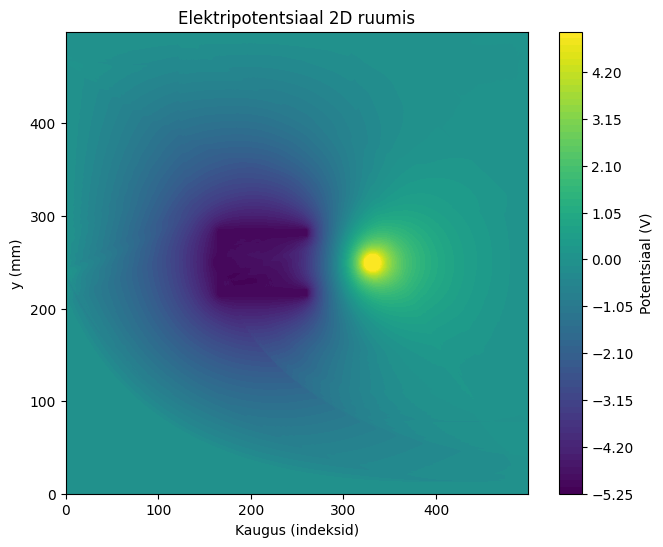

In [136]:
kuva(phi_IV_lahend, N_y_domain//2, N_x_domain//2, levels = 100)

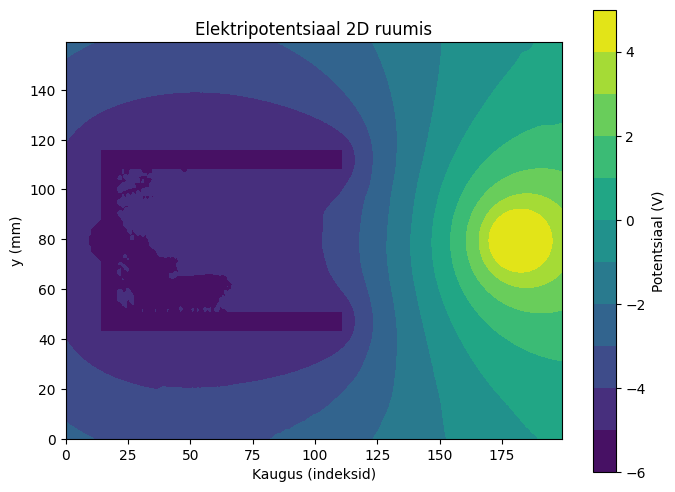

In [132]:
kuva(phi_IV_lahend, 80, 100, levels = 10)

In [133]:
#kuva_lõige_x(np.diff(phi_IV_lahend)/0.1, N_y//5, N_y//2, 
             #tekst = "Elektriväli diferentsmeetodil", y_l = "E (V/cm)", x_l = "Asukoht (dm)")

## V KATSE: INSULEERIV JA JUHTIV RING KLEMMIDE VAHELISES PIIRKONNAS

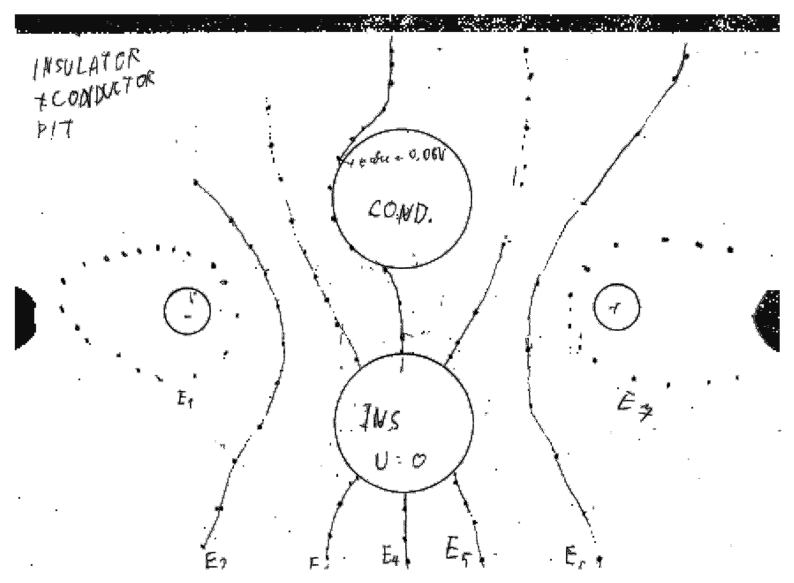

In [151]:
img = cv2.imread("insulator&conductor.jpg", cv2.IMREAD_GRAYSCALE)
img_contrast = cv2.equalizeHist(img)
plt.figure(figsize=(10,10))
plt.imshow(img_contrast, cmap = "gray")
plt.axis('off')
plt.show()

Hinnangud kondensaatorite vahelisele elektriväljale igas vahemikus:
114, 78, 57, 50, 45, 62, 83, 125 V/m


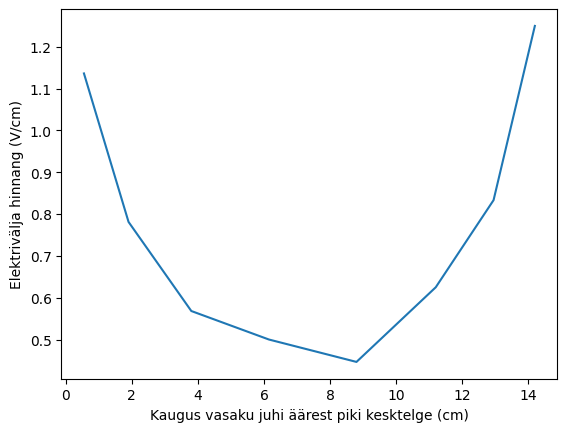

In [152]:
#iga potentsiaalijoone pinge vahe (8 vahemikku, 10 voldine pingelang):
U_i = 10/8 #V

#sentimeetrites:
d_E1 = 1.1
d_E2 = 2.7
d_E3 = 4.9
d_E4 = 7.4
d_E5 = 10.2
d_E6 = 12.2
d_E7 = 13.7
kondensaatorite_vahekaugus = 14.7

#elektrivälja tugevuse hinnangud kaheksas vahemikus
E01 = U_i/(d_E1)
E12 = U_i/(d_E2-d_E1)
E23 = U_i/(d_E3-d_E2)
E34 = U_i/(d_E4-d_E3)
E45 = U_i/(d_E5-d_E4)
E56 = U_i/(d_E6-d_E5)
E67 = U_i/(d_E7-d_E6)
E78 = U_i/(kondensaatorite_vahekaugus-d_E7)


vahemiku_keskosad = (np.array([d_E1,d_E2,d_E3,d_E4,d_E5,d_E6,d_E7,kondensaatorite_vahekaugus]) +\
        np.array([0, d_E1,d_E2,d_E3,d_E4,d_E5,d_E6,d_E7]))/2
print("Hinnangud kondensaatorite vahelisele elektriväljale igas vahemikus:")

print(", ".join(f"{(100*E):.0f}" for E in [E01, E12, E23, E34, E45, E56, E67, E78]) + " V/m")
plt.plot(vahemiku_keskosad,[E01, E12, E23, E34, E45, E56, E67, E78])
plt.ylabel("Elektrivälja hinnang (V/cm)")
plt.xlabel("Kaugus vasaku juhi äärest piki kesktelge (cm)")
plt.show()

In [12]:
raadius_V = 9#raadius_III
vahekaugus_V = 148 + 2*raadius_V #mm
Raadius_V = 27 #mm
Vahekaugus_V = 33 + 2*Raadius_V #mm

### DIELEKTRIKU PUHUL VAJA KAARDISTADA KA ELEKTRILIST LÄBITAVUST

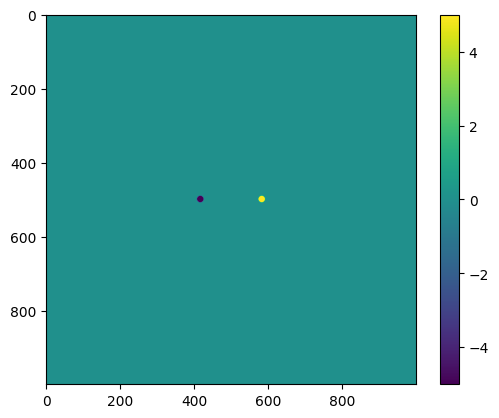

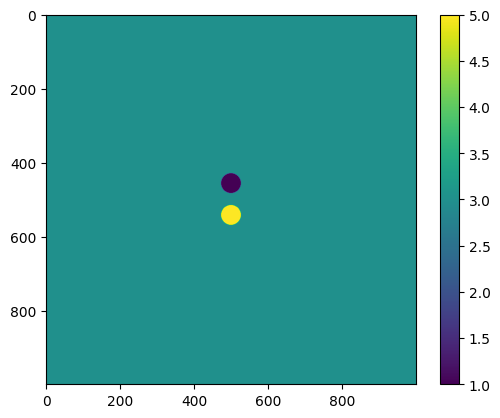

In [27]:
phi_V = np.zeros((N_y_domain, N_x_domain))
vaba_ruum_V = np.ones((N_y_domain, N_x_domain), dtype=bool)
epsilonid_V = 3*np.ones((N_y_domain, N_x_domain))

#ringide joonistamine
x_C1 = N_x_domain//2 - vahekaugus_V//2
x_C2 = N_x_domain//2 + vahekaugus_V//2
y_C1 = y_C2 = N_y_domain//2

y_space = np.linspace(0, N_y_domain, N_y_domain)
x_space = np.linspace(0, N_x_domain, N_x_domain)

y_ring1, x_ring1 = np.meshgrid( x_space-x_C1, y_space-y_C1)
raadiused1 = np.sqrt(x_ring1**2 + y_ring1**2)

y_ring2, x_ring2 = np.meshgrid( x_space-x_C2, y_space-y_C2)
raadiused2 = np.sqrt(x_ring2**2 + y_ring2**2)

phi_V[(raadiused1 <= raadius_V)] = -5
vaba_ruum_V[(raadiused1 <= raadius_V)] = False
phi_V[(raadiused2 <= raadius_V)] = 5
vaba_ruum_V[(raadiused2 <= raadius_V)] = False


#Suurte ringide joonistamine
y_C1 = N_y_domain//2 - Vahekaugus_V//2
y_C2 = N_y_domain//2 + Vahekaugus_V//2
x_C1 = x_C2 = N_x_domain//2

y_space = np.linspace(0, N_y_domain, N_y_domain)
x_space = np.linspace(0, N_x_domain, N_x_domain)

y_ring1, x_ring1 = np.meshgrid( x_space-x_C1, y_space-y_C1)
raadiused1 = np.sqrt(x_ring1**2 + y_ring1**2)

y_ring2, x_ring2 = np.meshgrid( x_space-x_C2, y_space-y_C2)
raadiused2 = np.sqrt(x_ring2**2 + y_ring2**2)

#phi_V[(raadiused1 <= Raadius_V)] = -5
#vaba_ruum_V[(raadiused1 <= Raadius_V)] = False

epsilonid_V[(raadiused1 <= Raadius_V)] = 1

#phi_V[(raadiused2 <= Raadius_V)] = 5
#vaba_ruum_V[(raadiused2 <= Raadius_V)] = False

epsilonid_V[(raadiused2 <= Raadius_V)] = 5

#järgnevat pole tegelikult vaja, sest, SOR implementatsioon ei arvesta nendega: 
vaba_ruum_V[0,:] = vaba_ruum_V[-1,:] = vaba_ruum_V[:,0]=vaba_ruum_V[:,-1] = False

plt.imshow(phi_V)
plt.colorbar()
plt.show()

plt.imshow(epsilonid_V)
plt.colorbar()
plt.show()

In [28]:
phi_V_lahend = LaplaceSOR_läbitavusega(phi_V, vaba_ruum_V, epsilonid_V, 120, opt_omega(N_x_domain, N_y_domain))

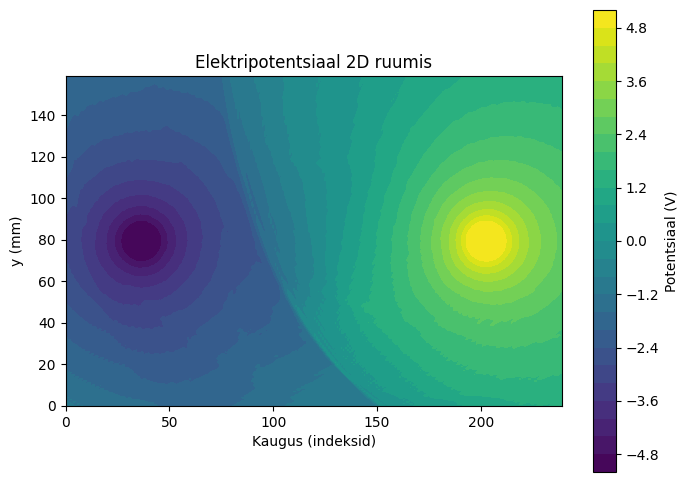

In [31]:
kuva(phi_V_lahend, 80, 120, levels = 25)

dielektriku e_r = 30 puhul:

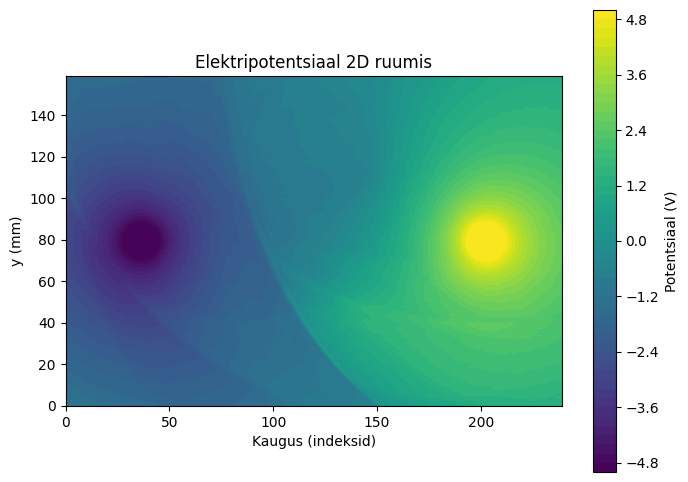